In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [2]:
dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

_______
# Data

In [3]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [base_dic]
l = ['L3-2km',]
ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [base_dic]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)

307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_28794/2043397947.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


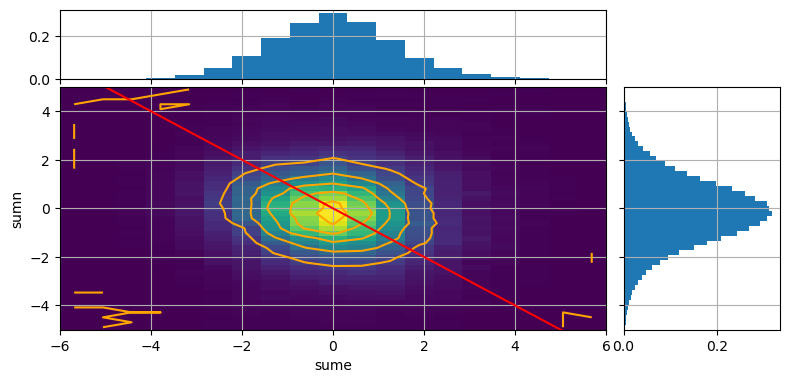

In [10]:
def plot_join_pdfs(ds, x, y, binx=100, biny=100):
    nsamples, yy, xx = np.histogram2d(ds[y], ds[x], bins=(biny, binx))
    da = xr.DataArray(data=nsamples, dims=[y, x],coords={x:([x], (xx[:-1] + xx[1:])/2), y:([y], (yy[:-1] + yy[1:])/2)})
    
    fig = plt.figure(figsize=(9, 4))
    
    # Add a gridspec with two rows and two columns and a ratio of 2 to 7 between
    # the size of the marginal axes and the main axes in both directions.
    # Also adjust the subplot parameters for a square plot.
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(7, 2),
        height_ratios=(2, 7),
        left=0.1,
        right=0.9,
        bottom=0.1,
        top=0.9,
        wspace=0.05,
        hspace=0.05,
    )
    
    ax = fig.add_subplot(gs[1, 0])
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
    

    
    da.plot(ax=ax, add_colorbar=False)
    da.plot.contour(ax=ax, add_colorbar=False, colors='orange')
    ax.plot(xx, -xx, color='r')
    ds[x].plot.hist(bins=binx, density=True, ax=ax_histx, zorder=1)
    ds[y].plot.hist(
        bins=biny,
        density=True,
        ax=ax_histy,
        orientation="horizontal",
        zorder=1,
    )


    # no labels
    ax.grid(zorder=0)
    ax_histx.grid()
    ax_histy.grid()
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.set_title('')
    ax_histx.set_title('')
    ax_histy.set_xlabel('')
    ax_histx.set_xlabel('')
    fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)

    

plot_join_pdfs(DSS, 'sume', 'sumn', binx=np.linspace(-6, 6, 20), biny=np.linspace(-5, 5, 50))

____________
# PDFS

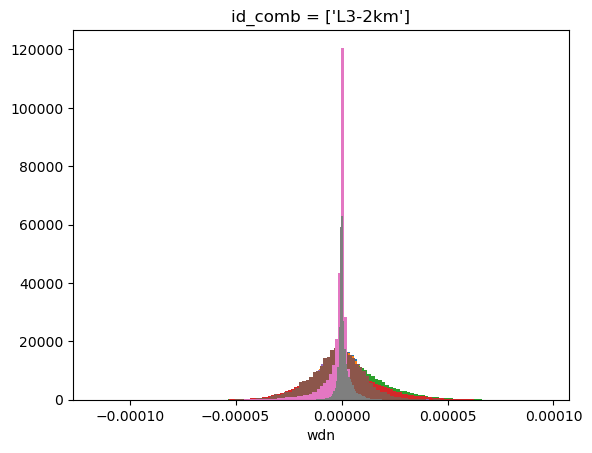

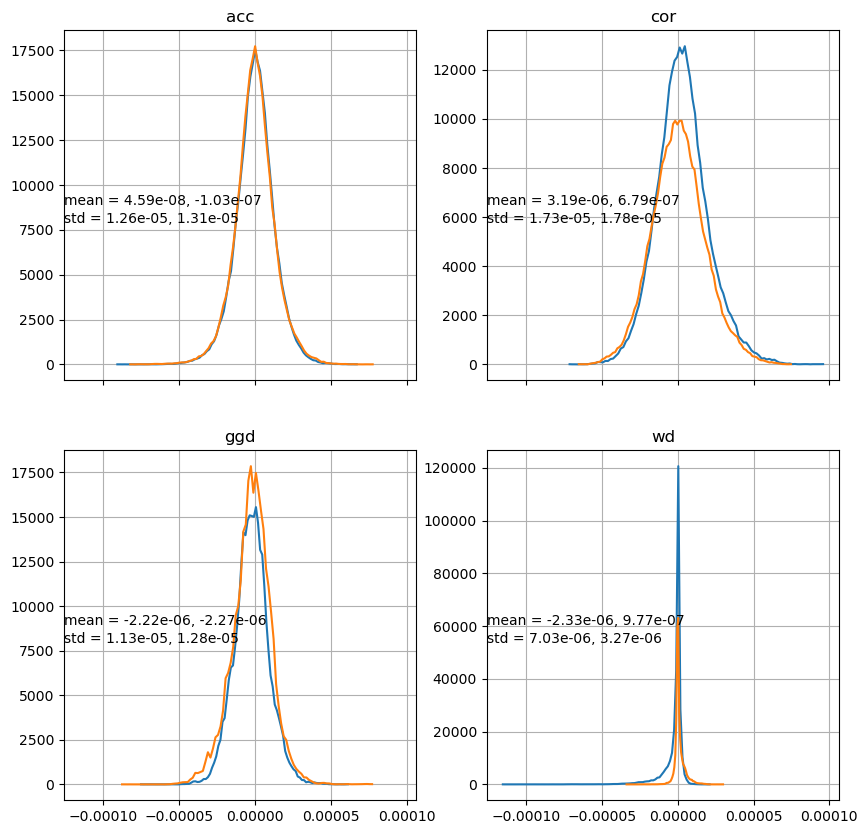

In [34]:
f,m = plt.subplots(1, 1)

def plot_pdfs(v, ax):
    h,b,_ = DS[v].plot.hist(bins=100, ax=m)
    b=(b[1:] + b[:-1])/2
    ax.plot(b, h, label = v)


v=['acc', 'cor', 'ggd', 'wd']
dir_ = ['e', 'n']


fig, axs = plt.subplots(2, 2, figsize=(10, 10), frameon=False, sharex=True)
axs = axs.flatten()

for i in range(4):
    for d in dir_:
        plot_pdfs(v[i]+d, axs[i])
        axs[i].set_title(v[i])
    axs[i].annotate(f"mean = {np.format_float_scientific(DS[v[i]+'e'].mean().values, 2)}, {np.format_float_scientific(DS[v[i]+'n'].mean().values, 2)}", (0,0.5), xycoords='axes fraction',)
    axs[i].annotate(f"std = {np.format_float_scientific(DS[v[i]+'e'].std().values, 2)}, {np.format_float_scientific(DS[v[i]+'n'].std().values, 2)}", (0, 0.45), xycoords='axes fraction',)
for ax in axs :
    ax.grid()


    

______
# Distribution

In [35]:
DSS=DS

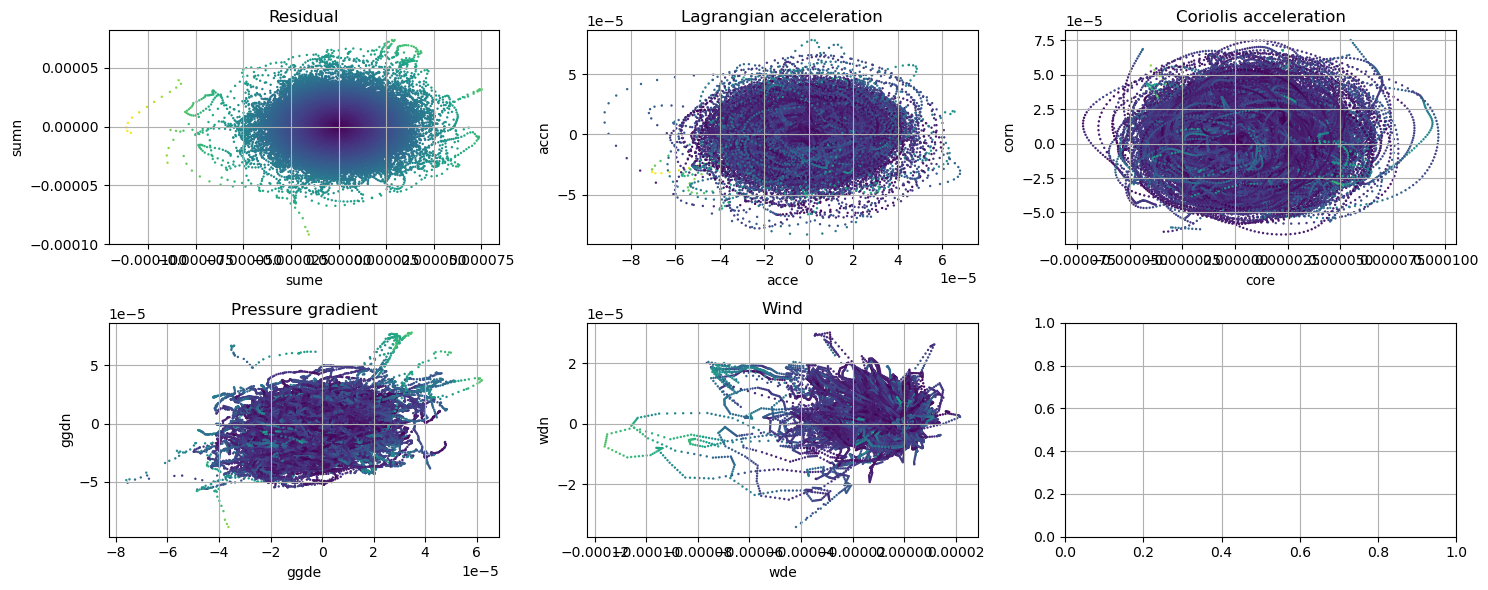

In [36]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6))
axs = axs.flatten()
r=30
s=3
c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r

ax=axs[0]
DSS.plot.scatter(x='sume', y='sumn',s=s, c=c,lw=0,  ax=ax)
ax.set_title('Residual')

ax=axs[1]
DSS.plot.scatter(x='acce', y='accn',s=s, c=c, lw=0,ax=ax)
ax.set_title('Lagrangian acceleration')

ax=axs[2]
DSS.plot.scatter(x='core',y= 'corn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Coriolis acceleration')

ax=axs[3]
DSS.plot.scatter(x='ggde', y='ggdn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Pressure gradient')

ax=axs[4]
DSS.plot.scatter(x='wde', y='wdn',s=s, c=c, lw=0, ax=ax)
ax.set_title('Wind')


for ax in axs :
    ax.grid()

fig.tight_layout()


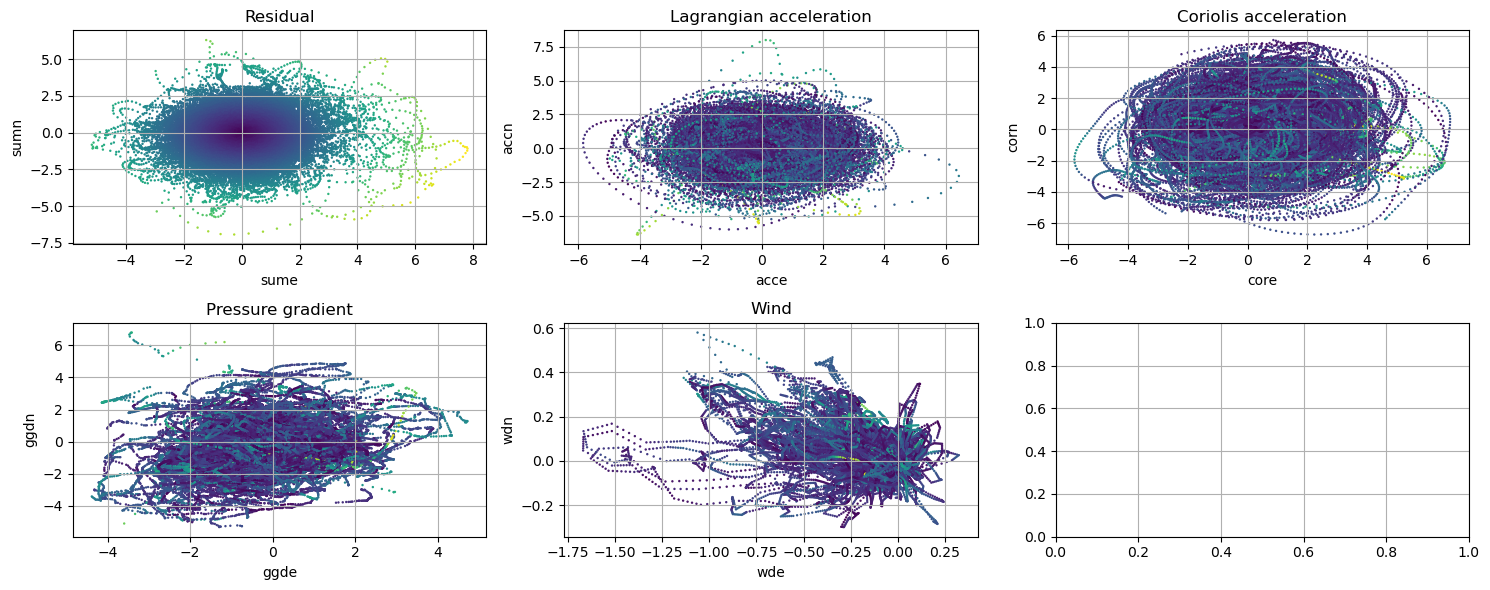

In [54]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6))
axs = axs.flatten()
r=30
s=3
c = np.sqrt(DSD.sume**2+DSD.sumn**2)*r

ax=axs[0]
DSD.plot.scatter(x='sume', y='sumn',s=s, c=c,lw=0,  ax=ax)
ax.set_title('Residual')

ax=axs[1]
DSD.plot.scatter(x='acce', y='accn',s=s, c=c, lw=0,ax=ax)
ax.set_title('Lagrangian acceleration')

ax=axs[2]
DSD.plot.scatter(x='core',y= 'corn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Coriolis acceleration')

ax=axs[3]
DSD.plot.scatter(x='ggde', y='ggdn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Pressure gradient')

ax=axs[4]
DSD.plot.scatter(x='wde', y='wdn',s=s, c=c, lw=0, ax=ax)
ax.set_title('Wind')


for ax in axs :
    ax.grid()

fig.tight_layout()


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_28794/2043397947.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


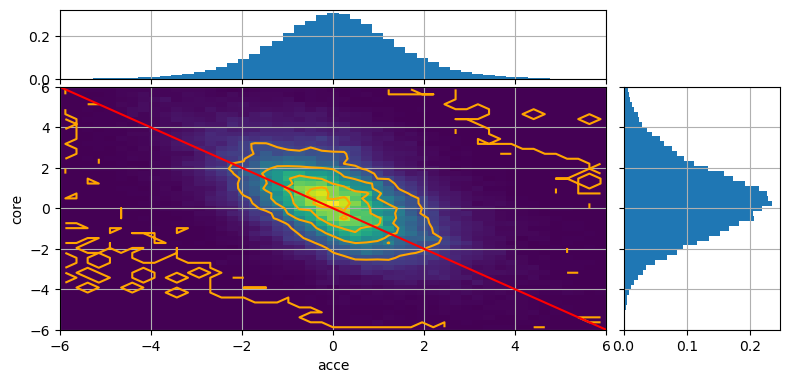

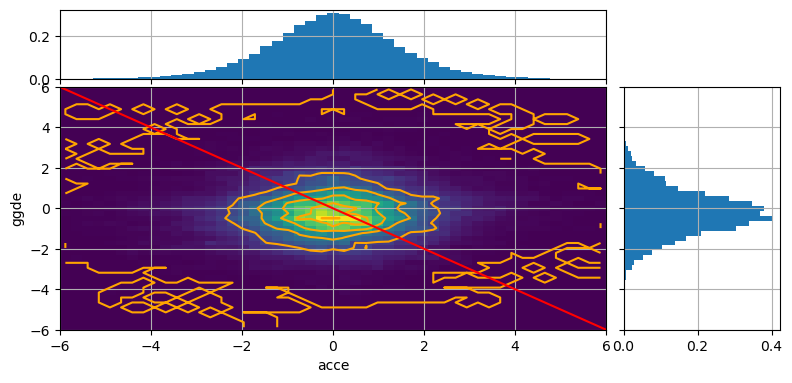

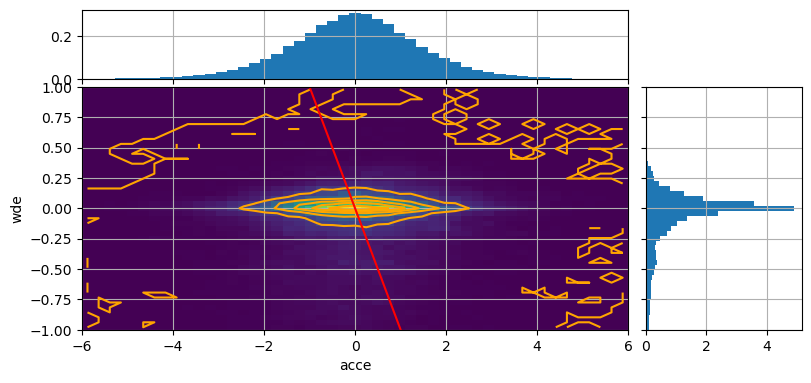

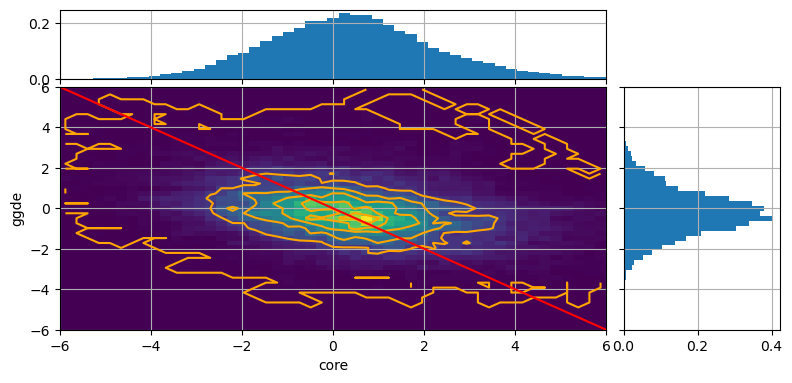

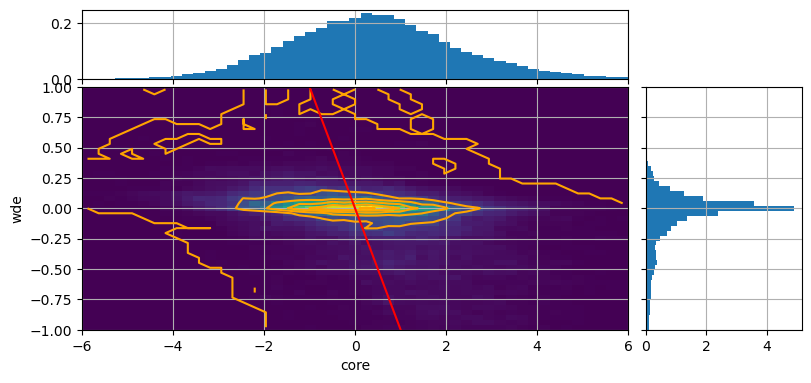

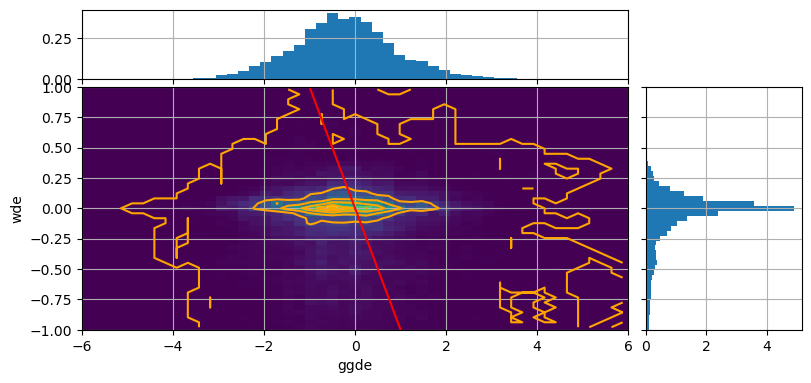

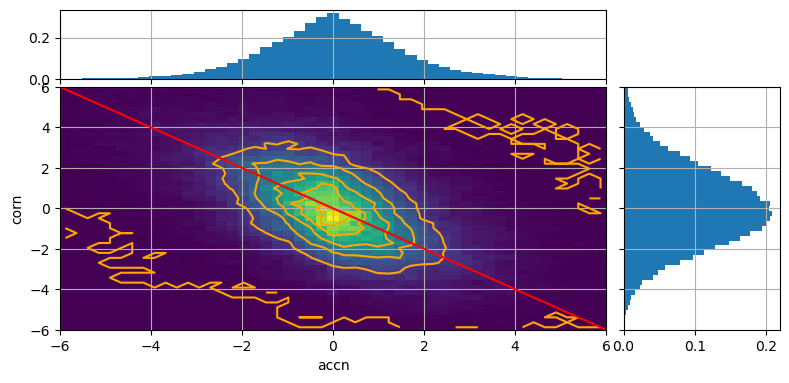

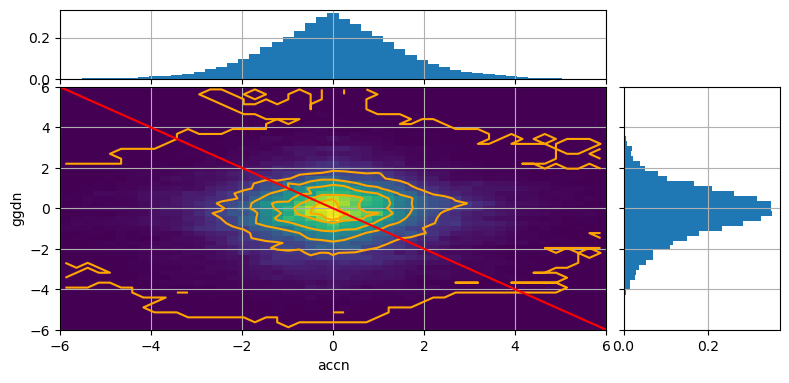

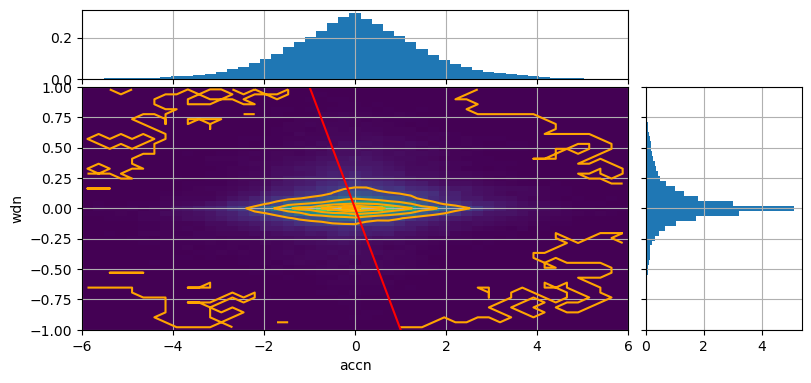

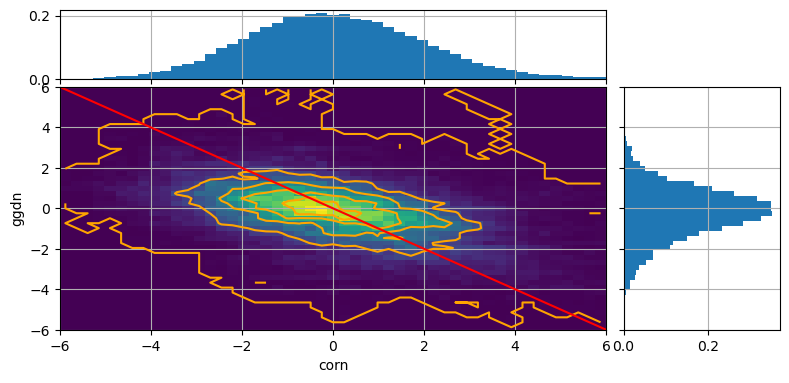

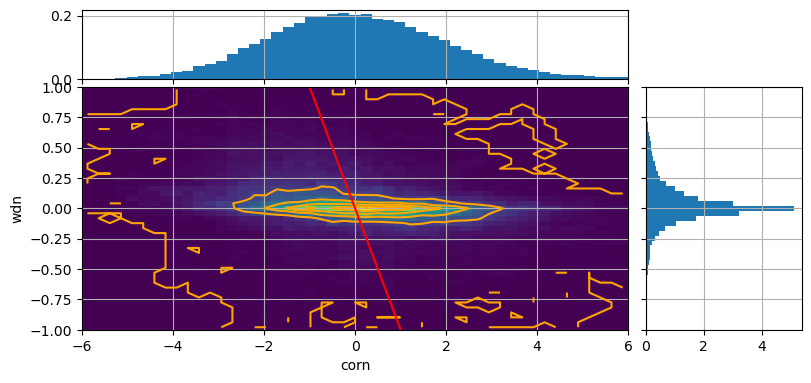

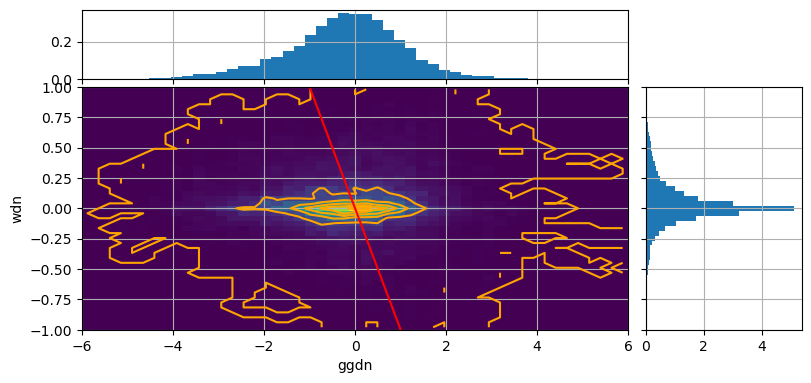

In [11]:
bins = np.linspace(-6, 6, 50)
wdbins = np.linspace(-1, 1, 50)

plot_join_pdfs(DSS, x='acce', y='core', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='acce', y='ggde', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='acce', y='wde', binx=bins, biny=wdbins)
plot_join_pdfs(DSS, x='core', y='ggde', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='core', y='wde', binx=bins, biny=wdbins)
plot_join_pdfs(DSS, x='ggde', y='wde', binx=bins, biny=wdbins)


plot_join_pdfs(DSS, x='accn', y='corn', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='accn', y='ggdn', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='accn', y='wdn', binx=bins, biny=wdbins)
plot_join_pdfs(DSS, x='corn', y='ggdn', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='corn', y='wdn', binx=bins, biny=wdbins)
plot_join_pdfs(DSS, x='ggdn', y='wdn', binx=bins, biny=wdbins)


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_28794/2043397947.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])  # left, bottom, right, top (default is 0,0,1,1)


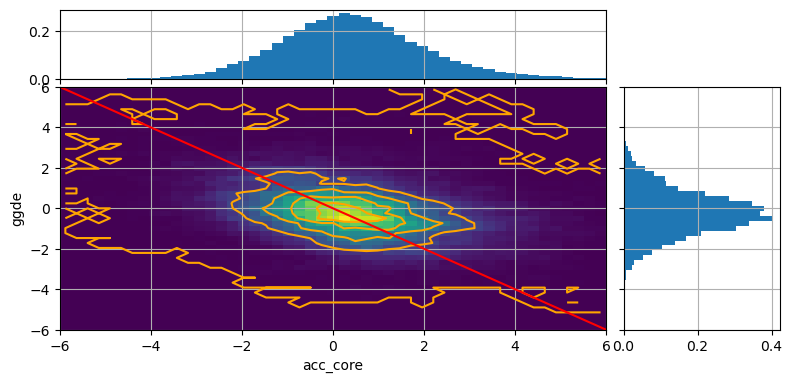

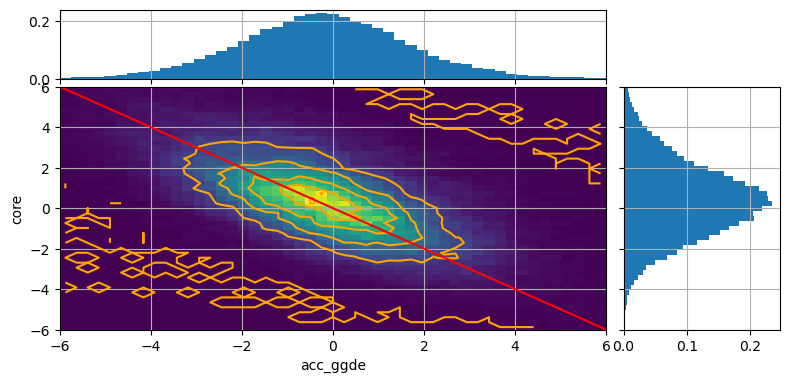

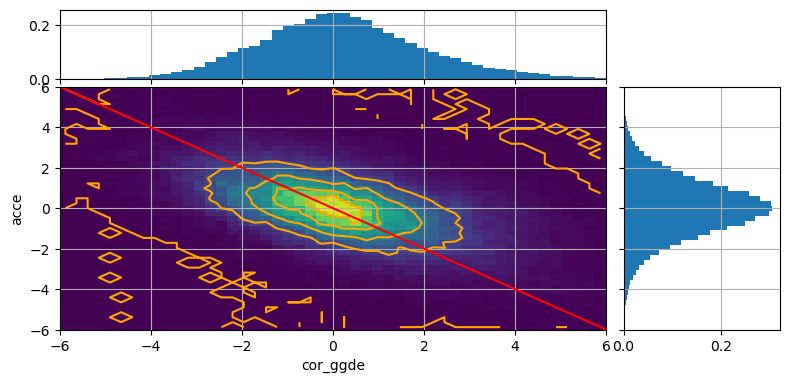

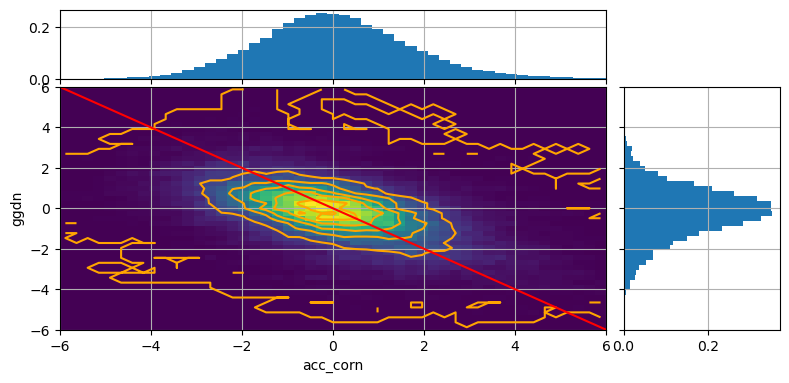

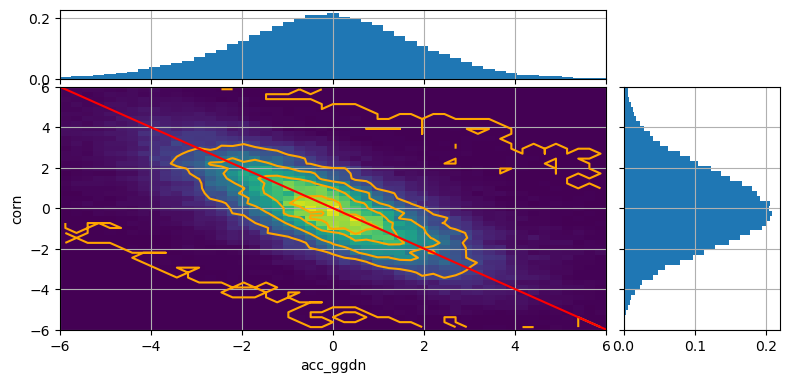

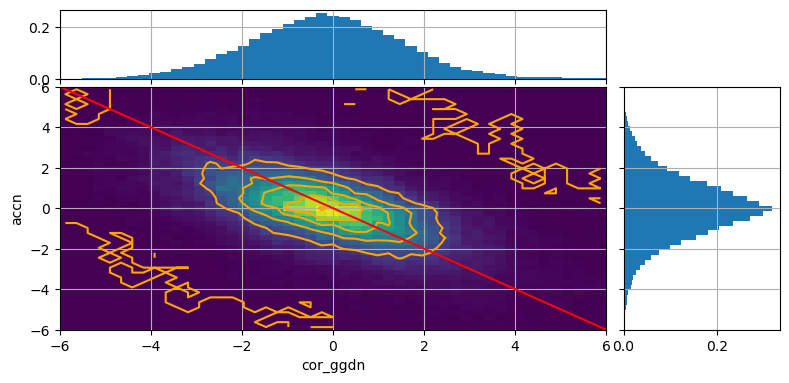

In [13]:
bins = np.linspace(-6, 6, 50)
wdbins = np.linspace(-1, 1, 50)

for dir_ in ['e', 'n'] : 
    DSS['acc_cor'+dir_] = DSS['acc'+dir_] + DSS['cor'+dir_]
    DSS['acc_ggd'+dir_] = DSS['acc'+dir_] + DSS['ggd'+dir_]
    DSS['cor_ggd'+dir_] = DSS['cor'+dir_] + DSS['ggd'+dir_]


plot_join_pdfs(DSS, x='acc_core', y='ggde', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='acc_ggde', y='core', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='cor_ggde', y='acce', binx=bins, biny=bins)

plot_join_pdfs(DSS, x='acc_corn', y='ggdn', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='acc_ggdn', y='corn', binx=bins, biny=bins)
plot_join_pdfs(DSS, x='cor_ggdn', y='accn', binx=bins, biny=bins)


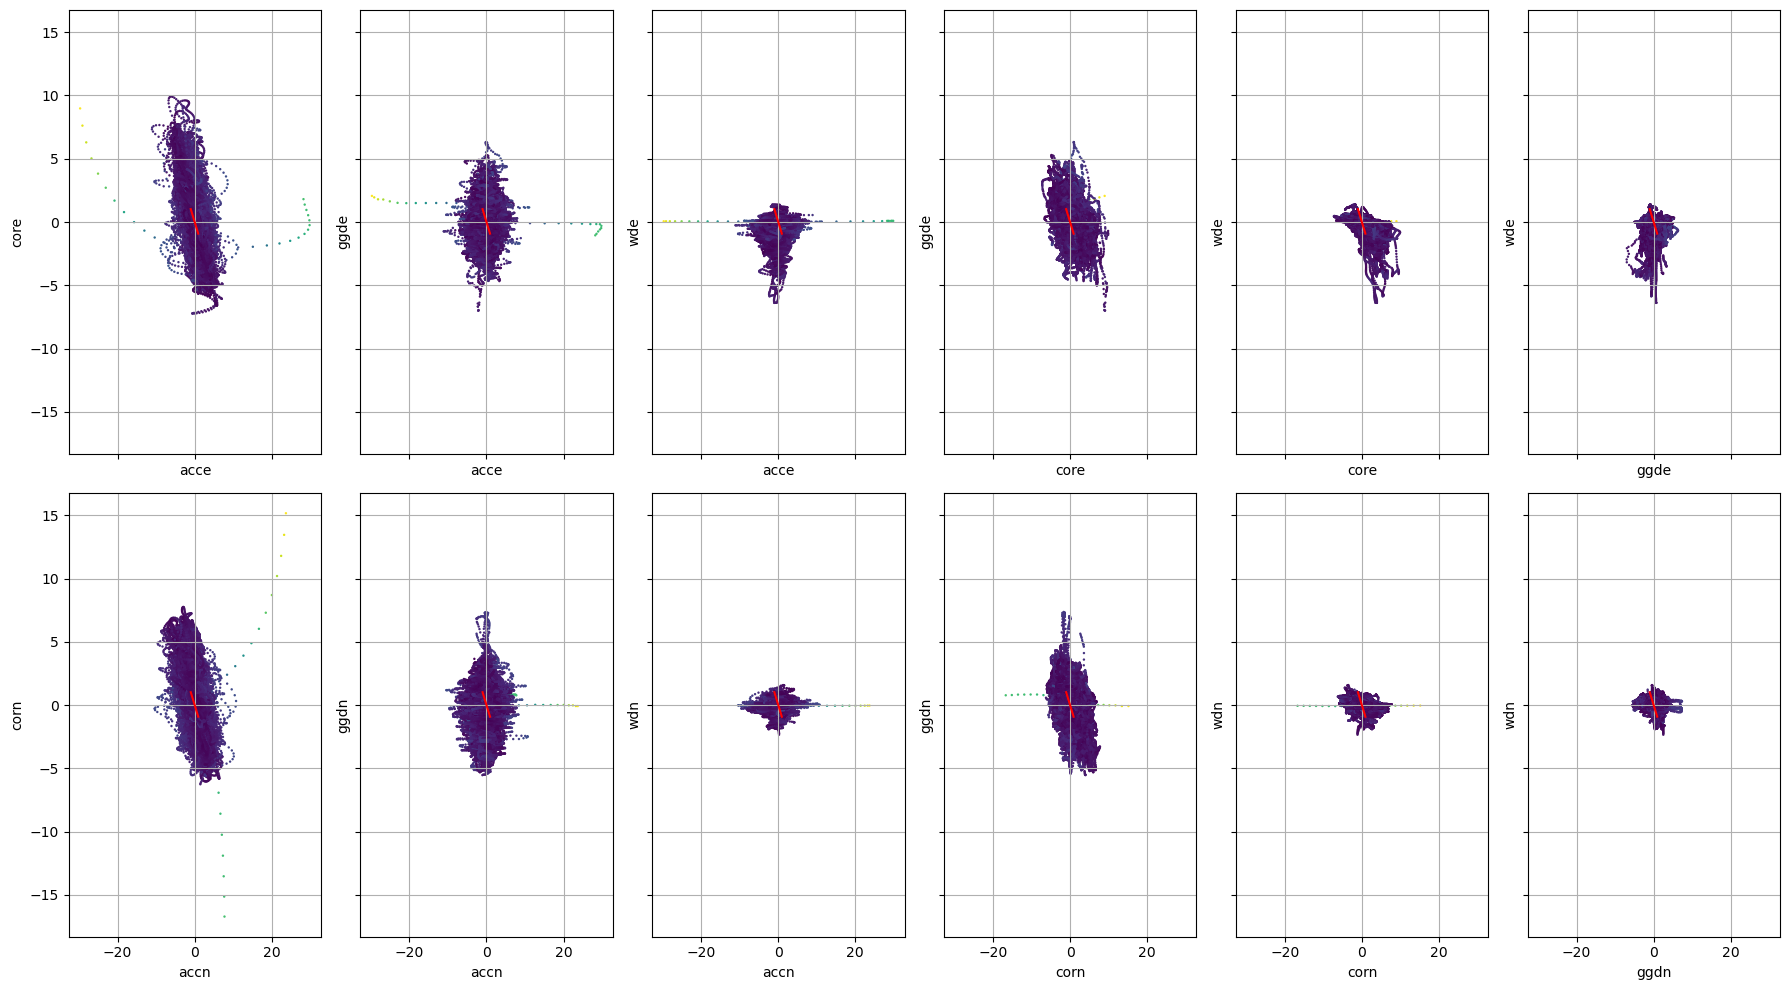

In [55]:
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(18, 10), sharex=True, sharey=True)
axs =axs.flatten()

r=30
s=3
c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r

DSS.plot.scatter(x='acce', y='core', s = s,c=c,lw=0, ax=axs[0])
DSS.plot.scatter(x='acce', y='ggde', s = s,c=c,lw=0, ax=axs[1])
DSS.plot.scatter(x='acce', y='wde', s = s,c=c,lw=0, ax=axs[2])
DSS.plot.scatter(x='core', y='ggde', s = s,c=c,lw=0, ax=axs[3])
DSS.plot.scatter(x='core', y='wde', s = s,c=c,lw=0, ax=axs[4])
DSS.plot.scatter(x='ggde', y='wde', s = s,c=c,lw=0, ax=axs[5])


DSS.plot.scatter(x='accn', y='corn', s = s,c=c,lw=0, ax=axs[6])
DSS.plot.scatter(x='accn', y='ggdn', s = s,c=c,lw=0, ax=axs[7])
DSS.plot.scatter(x='accn', y='wdn', s = s,c=c,lw=0, ax=axs[8])
DSS.plot.scatter(x='corn', y='ggdn', s = s,c=c,lw=0, ax=axs[9])
DSS.plot.scatter(x='corn', y='wdn', s = s,c=c,lw=0, ax=axs[10])
DSS.plot.scatter(x='ggdn', y='wdn', s = s,c=c,lw=0, ax=axs[11])


x = np.arange(-1e-5/U, 1e-5/U, 1e-6/U)
for ax in axs:
    ax.grid()
#    ax.plot(x, x, c='grey')
    ax.plot(x, -x, c='r')
    
    ax.set_title('')

fig.tight_layout()

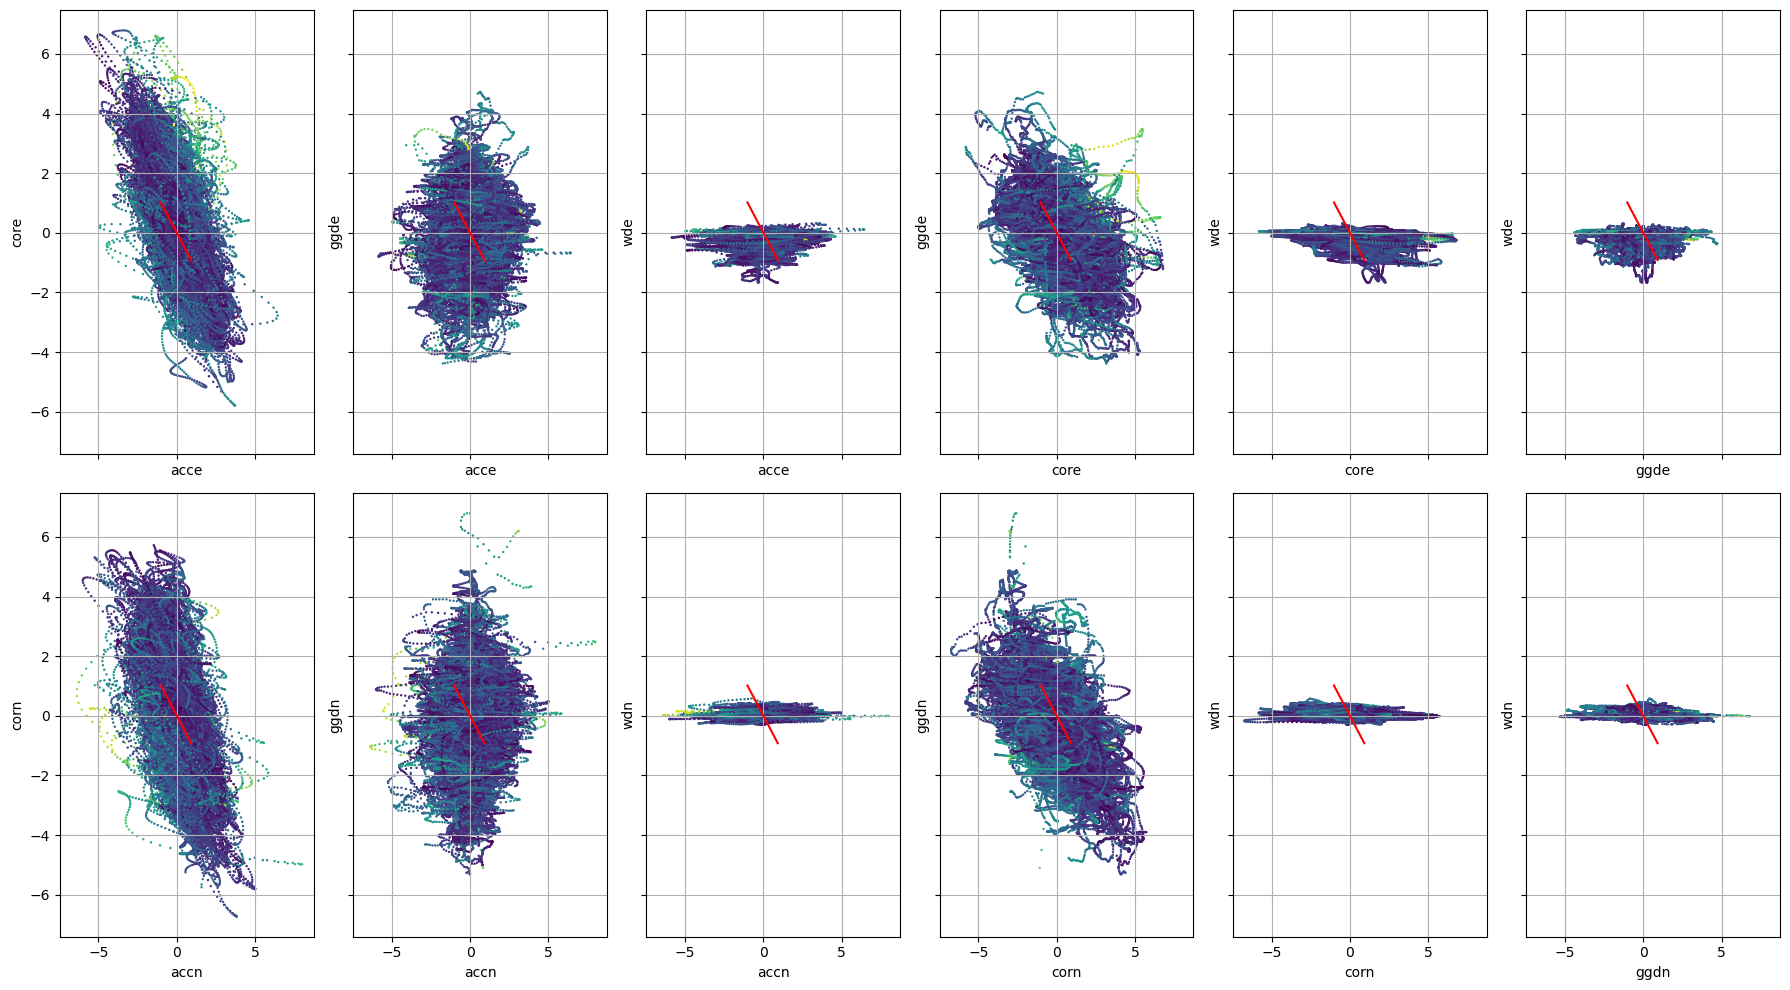

In [55]:
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(18, 10), sharex=True, sharey=True)
axs =axs.flatten()

r=30
s=3
c = np.sqrt(DSD.sume**2+DSD.sumn**2)*r

DSD.plot.scatter(x='acce', y='core', s = s,c=c,lw=0, ax=axs[0])
DSD.plot.scatter(x='acce', y='ggde', s = s,c=c,lw=0, ax=axs[1])
DSD.plot.scatter(x='acce', y='wde', s = s,c=c,lw=0, ax=axs[2])
DSD.plot.scatter(x='core', y='ggde', s = s,c=c,lw=0, ax=axs[3])
DSD.plot.scatter(x='core', y='wde', s = s,c=c,lw=0, ax=axs[4])
DSD.plot.scatter(x='ggde', y='wde', s = s,c=c,lw=0, ax=axs[5])


DSD.plot.scatter(x='accn', y='corn', s = s,c=c,lw=0, ax=axs[6])
DSD.plot.scatter(x='accn', y='ggdn', s = s,c=c,lw=0, ax=axs[7])
DSD.plot.scatter(x='accn', y='wdn', s = s,c=c,lw=0, ax=axs[8])
DSD.plot.scatter(x='corn', y='ggdn', s = s,c=c,lw=0, ax=axs[9])
DSD.plot.scatter(x='corn', y='wdn', s = s,c=c,lw=0, ax=axs[10])
DSD.plot.scatter(x='ggdn', y='wdn', s = s,c=c,lw=0, ax=axs[11])


x = np.arange(-1e-5/U, 1e-5/U, 1e-6/U)
for ax in axs:
    ax.grid()
#    ax.plot(x, x, c='grey')
    ax.plot(x, -x, c='r')
    
    ax.set_title('')

fig.tight_layout()

# PDF

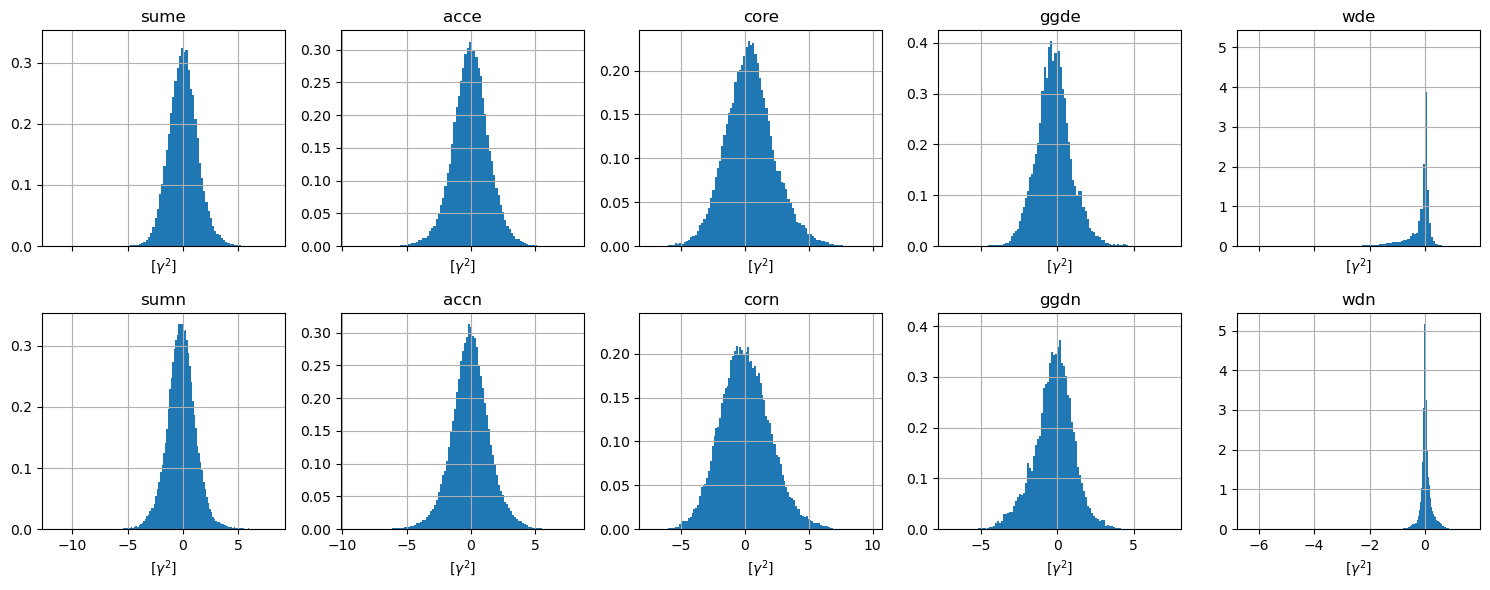

In [53]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6), sharey='col', sharex='col')
axs = axs.flatten()
r=30
s=3
#c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r
i=0
for dir in ['e', 'n'] :
    for v in ['sum', 'acc', 'cor', 'ggd', 'wd']:
        ax = axs[i]
        DSS[v + dir].plot.hist(ax=ax, bins=100, density=True)
        ax.set_title(v+dir)
        ax.set_xlabel(r'[$\gamma^2$]')
        i+=1

for ax in axs :
    ax.grid()

fig.tight_layout()


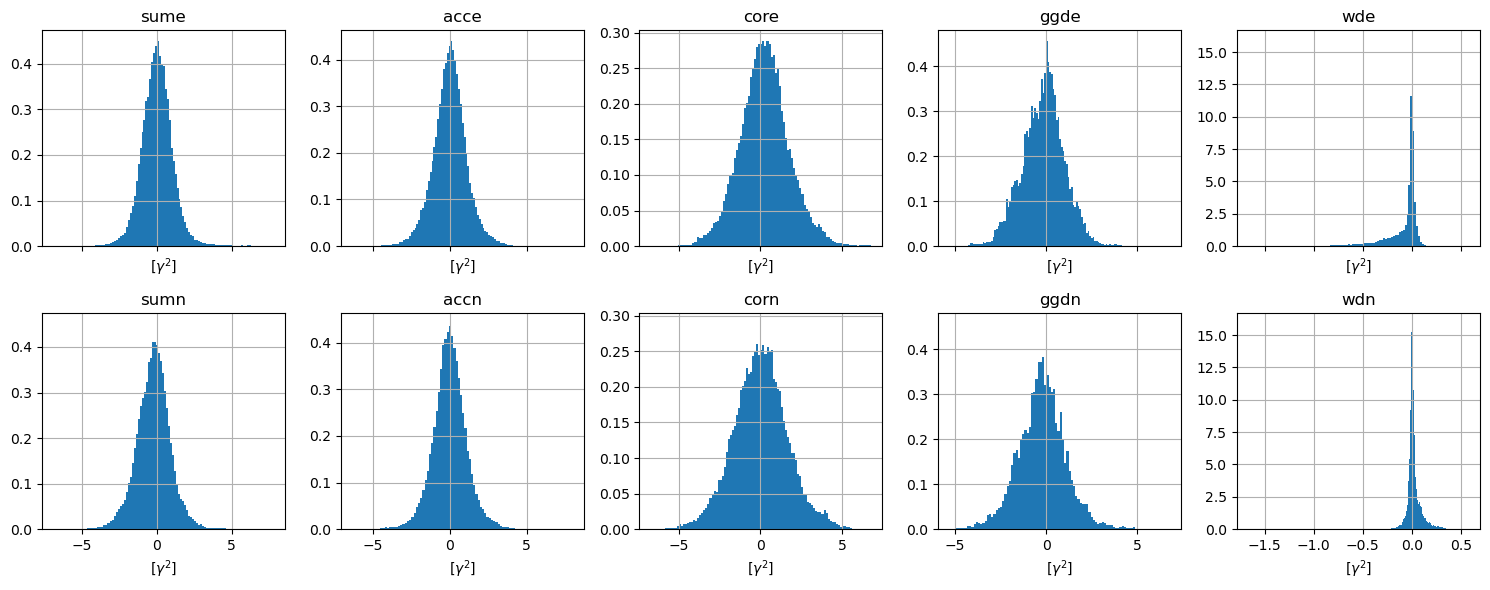

In [56]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6), sharey='col', sharex='col')
axs = axs.flatten()
r=30
s=3
#c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r
i=0
for dir in ['e', 'n'] :
    for v in ['sum', 'acc', 'cor', 'ggd', 'wd']:
        ax = axs[i]
        DSD[v + dir].plot.hist(ax=ax, bins=100, density=True)
        ax.set_title(v+dir)
        ax.set_xlabel(r'[$\gamma^2$]')
        i+=1

for ax in axs :
    ax.grid()

fig.tight_layout()
